### Introduction
This project aims to classify the sentiment of tweets directed at various US airlines into three categories: Negative, Neutral, or Positive. Using a dataset of ~14,640 tweets, we implement an Object-Oriented pipeline to preprocess text, extract features using TF-IDF, and train a Multi-Layer Feed-Forward Neural Network.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kostas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Kostas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Kostas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset Shape: (14640, 15)


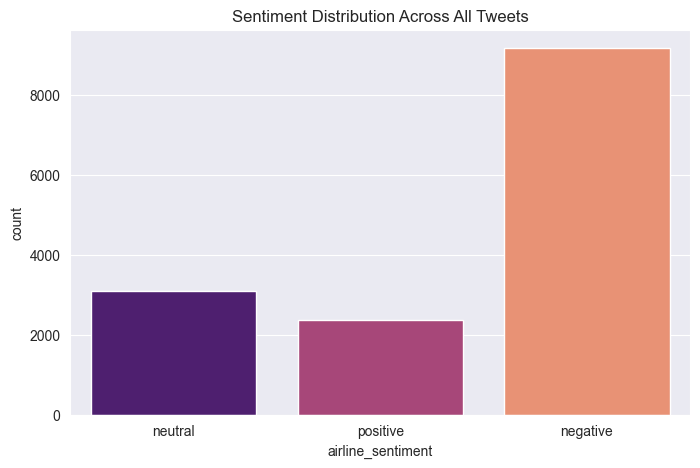

Class distribution (%) :
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64
Preprocessing tweets... please wait.

--- Preprocessing Sample ---
Original: @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
Processed: really aggressive blast obnoxious entertainment guest face amp little recourse


In [1]:
from src import TextPreprocessor, FeatureExtractor, SentimentANN, ModelTrainer, Evaluator

from sympy import false
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load Dataset
df = pd.read_csv('../Datasets/Tweets.csv')

# Display first few rows and basic info
print(f"Dataset Shape: {df.shape}")
df.head()

# Basic EDA: Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='airline_sentiment', data=df, hue = 'airline_sentiment', legend=false, palette='magma')
plt.title('Sentiment Distribution Across All Tweets')
plt.show()

# Calculate exact percentages for the report
print("Class distribution (%) :")
print(df['airline_sentiment'].value_counts(normalize=True) * 100)

# 3. Apply Preprocessing
preprocessor = TextPreprocessor()
df = preprocessor.run(df)

# Show a before/after sample for the notebook commentary
print("\n--- Preprocessing Sample ---")
print(f"Original: {df['text'].iloc[3]}")
print(f"Processed: {df['processed_text'].iloc[3]}")

#### Cleaning Logic
    Twitter data is notoriously "noisy." Our TextPreprocessor class handles:
    - Handle Removal: Removing @user mentions as they don't contribute to general sentiment.
    - URL/Noise Scrubbing: Stripping links and special characters.
    - Sentiment Preservation: We explicitly removed negation words (like "not", "no") from the NLTK stopword list. This
      ensures that a tweet saying "not happy" doesn't get reduced to just "happy."
    - Lemmatization: Reducing words to their root form (e.g., "delayed" and "delaying" both become "delay") to reduce
      feature dimensionality.
#### EDA Insights
     During EDA, we observed a significant class imbalance. Negative tweets dominate the dataset. This insight is crucial
     because it dictates that Accuracy will be a misleading metric; a model could achieve high accuracy just by guessing
     "Negative" every time. We must rely on F1-Score and the Confusion Matrix.

In [2]:
# Vectorization (Feature Extraction)
print("--- Vectorization ---")
extractor = FeatureExtractor(max_features=5000)
X, y = extractor.fit_transform(df)

# Split the data: 80% for training, 20% for testing
# We use 'stratify=y' to ensure the imbalance is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nFeature Extraction Complete!")
print(f"Number of input features: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Label Mapping: {dict(zip(extractor.label_encoder.classes_, range(3)))}")

--- Vectorization ---
Extracting features from processed_text...

Feature Extraction Complete!
Number of input features: 5000
Training samples: 11696
Label Mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


#### Feature Extraction (Vectorization)
    We chose TF-IDF (Term Frequency-Inverse Document Frequency) for this project because it is excellent at identifying "keyword" signals (like "delayed"
    or "broken") that are rare in general speech but common in specific sentiment categories.
    Unlike simple counting, TF-IDF penalizes common words and rewards "discriminative" words. In airline tweets, words
    like "cancelled", "lost", or "thanks" are high-signal words that TF-IDF identifies effectively. We limited the features
    to the top 5,000 terms to maintain a manageable input size for the ANN.

##### Why use stratify = y ?
    Since our dataset has many more negative tweets than positive ones, stratify = y makes sure that both Training set and Testing set have the exact
    same percentage of negative/positive tweets. This is vital for a fair evaluation.

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Data Splitting & Tensor Conversion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

#### ANN Model Architecture
    The model is built as a Multi-Layer Perceptron (MLP) with the following enhancements:
    - Batch Normalization: Applied after linear layers to stabilize and speed up training by normalizing the inputs to
      each activation function.
    - Dropout (0.3 and 0.2): We use dropout layers to prevent overfitting. By randomly "turning off" neurons during training,
      we force the network to learn robust patterns rather than memorizing the training data.
    - ReLU Activation: Used in hidden layers to introduce non-linearity.
    - Softmax/CrossEntropy: The final layer uses 3 neurons corresponding to our 3 classes, optimized via Cross-Entropy Loss.

In [ ]:
# Training with Early Stopping
print("--- Phase 3: Training ---")
model = SentimentANN(input_dim=X.shape[1])
trainer = ModelTrainer(model, lr=0.001, patience=5)
history = trainer.train_step(train_loader, test_loader, epochs=50)

#### Training Strategy & Early Stopping
    To ensure the model generalizes well, we implemented:
    - Early Stopping: We monitor the Validation Loss. If the loss does not improve for 5 consecutive epochs (patience=5),
      training terminates. This prevents the model from "chasing noise" in the training set.
    - Adam Optimizer: Chosen for its adaptive learning rate properties, which generally performs better on text classification
      tasks than standard SGD.

In [ ]:
# Final Evaluation
print("--- Phase 4: Evaluation ---")
evaluator = Evaluator()
evaluator.plot_loss(history[0], history[1])

# Generate predictions for the report
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, y_pred = torch.max(outputs, 1)

evaluator.report(
    y_test,
    y_pred.numpy(),
    target_names=extractor.label_encoder.classes_
)

#### Performance Evaluation
    Since our classes are imbalanced, we evaluate the model using:
    - Precision & Recall: To see if we are specifically missing "Positive" tweets (Recall) or mislabeling "Neutral"
      ones (Precision).
    - F1-Score: The harmonic mean of the two, providing a single robust score for each class.
    - Confusion Matrix: A visual tool to see exactly where the model is getting "confused"—for example, whether it struggles
      more with distinguishing Neutral from Negative or Neutral from Positive.